# 03 · Bayesian Estimation of Mean Daily Return

Use a **conjugate Normal-Normal model** to update a prior belief about the mean daily log return with observed data and summarise the posterior.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
import config

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({'figure.dpi': config.FIG_DPI})

## 1. Load Returns

In [ ]:
df = pd.read_csv(
    config.PROCESSED_DATA_CSV,
    index_col='Date', parse_dates=True
)
returns = df['LogReturn'].dropna()
n = len(returns)
x_bar = returns.mean()
s = returns.std()
print(f'Asset: {config.ASSET_NAME} ({config.ASSET_TICKER})')
print(f'n={n:,}  x̄={x_bar:.6f}  s={s:.6f}')

n=3,893  x̄=0.000260  s=0.011028


## 2. Conjugate Normal-Normal Update

**Model:** $r_i \sim \mathcal{N}(\mu, \sigma^2)$ with $\sigma$ known (set to sample std).  
**Prior:** $\mu \sim \mathcal{N}(\mu_0, \tau_0^2)$  
**Posterior:** $\mu \mid \mathbf{r} \sim \mathcal{N}(\mu_n, \tau_n^2)$

where
$$\tau_n^2 = \left(\frac{1}{\tau_0^2} + \frac{n}{\sigma^2}\right)^{-1}, \quad \mu_n = \tau_n^2 \left(\frac{\mu_0}{\tau_0^2} + \frac{n\bar{x}}{\sigma^2}\right)$$

In [3]:
def bayesian_normal_update(x_bar: float, n: int, sigma: float,
                            mu0: float, tau0: float) -> tuple:
    """
    Conjugate Normal-Normal posterior update.
    Returns (posterior_mean, posterior_std).
    """
    tau0_sq = tau0 ** 2
    sigma_sq = sigma ** 2
    tau_n_sq = 1.0 / (1.0 / tau0_sq + n / sigma_sq)
    mu_n = tau_n_sq * (mu0 / tau0_sq + n * x_bar / sigma_sq)
    return mu_n, np.sqrt(tau_n_sq)


prior_mean = config.PRIOR_MEAN
prior_std  = config.PRIOR_STD

post_mean, post_std = bayesian_normal_update(
    x_bar=x_bar, n=n, sigma=s,
    mu0=prior_mean, tau0=prior_std,
)
print(f'Prior     : μ₀={prior_mean:.4f}  τ₀={prior_std:.4f}')
print(f'Likelihood: x̄={x_bar:.6f}  σ={s:.6f}  n={n}')
print(f'Posterior : μₙ={post_mean:.6f}  τₙ={post_std:.8f}')

Prior     : μ₀=0.0000  τ₀=0.0100
Likelihood: x̄=0.000260  σ=0.011028  n=3893
Posterior : μₙ=0.000260  τₙ=0.00017672


## 3. Posterior Summary

In [4]:
ci_lo = stats.norm.ppf(0.025, loc=post_mean, scale=post_std)
ci_hi = stats.norm.ppf(0.975, loc=post_mean, scale=post_std)

print('\n=== Posterior Summary ===')
print(f'  Mean            : {post_mean:.6f}')
print(f'  Std dev (spread): {post_std:.2e}')
print(f'  95% Credible CI : [{ci_lo:.6f}, {ci_hi:.6f}]')
print(f'  (annualised mean ≈ {post_mean * 252:.4f})')


=== Posterior Summary ===
  Mean            : 0.000260
  Std dev (spread): 1.77e-04
  95% Credible CI : [-0.000086, 0.000606]
  (annualised mean ≈ 0.0655)


## 4. Prior vs Posterior Plot

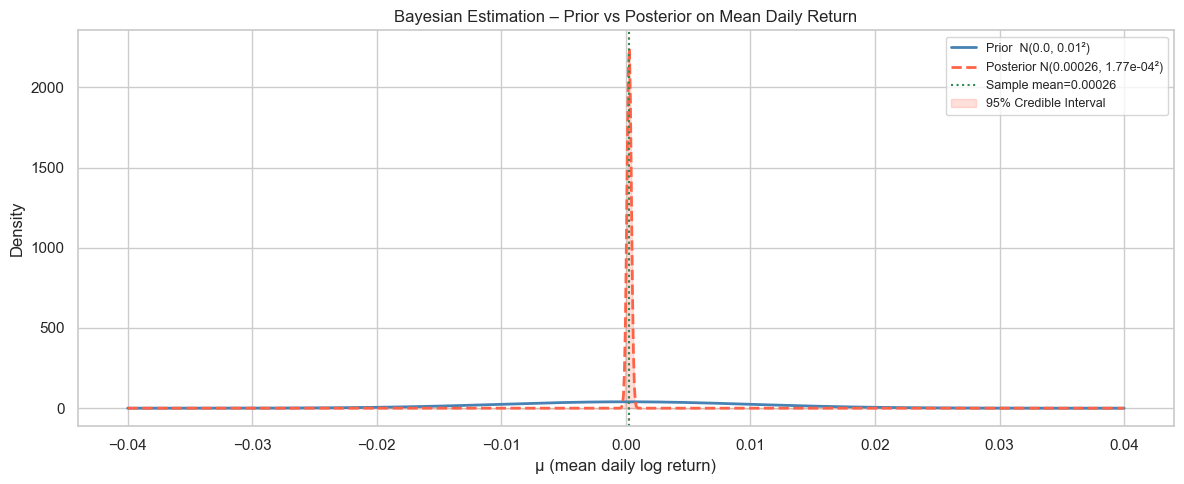

In [5]:
mu_range = np.linspace(prior_mean - 4 * prior_std, prior_mean + 4 * prior_std, 1000)

prior_pdf     = stats.norm.pdf(mu_range, loc=prior_mean, scale=prior_std)
posterior_pdf = stats.norm.pdf(mu_range, loc=post_mean,  scale=post_std)

fig, ax = plt.subplots(figsize=config.FIG_SIZE)
ax.plot(mu_range, prior_pdf,     label=f'Prior  N({prior_mean}, {prior_std}²)',
        color='steelblue', linewidth=2)
ax.plot(mu_range, posterior_pdf, label=f'Posterior N({post_mean:.5f}, {post_std:.2e}²)',
        color='tomato', linewidth=2, linestyle='--')
ax.axvline(post_mean, color='tomato', linestyle=':', linewidth=1.5)
ax.axvline(x_bar,     color='seagreen', linestyle=':', linewidth=1.5, label=f'Sample mean={x_bar:.5f}')
ax.fill_between(mu_range,
                np.where((mu_range >= ci_lo) & (mu_range <= ci_hi), posterior_pdf, 0),
                alpha=0.2, color='tomato', label='95% Credible Interval')
ax.set_title('Bayesian Estimation – Prior vs Posterior on Mean Daily Return')
ax.set_xlabel('μ (mean daily log return)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

- The prior curve is belief before data; the posterior is updated belief after data.
- A narrower posterior means uncertainty is reduced after observing returns.
- The posterior center is our updated estimate of mean daily return.

## 5. Sensitivity to Prior

Show how the posterior mean shifts for several prior standard deviations.

C:\Users\User\AppData\Local\Temp\ipykernel_21184\2275475237.py:13: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_21184\2275475237.py:13: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


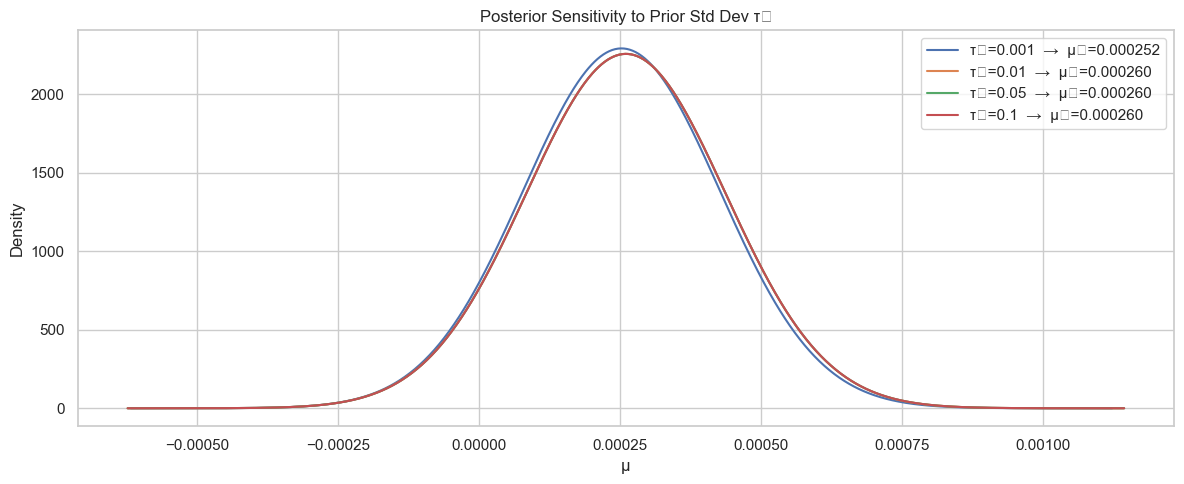

In [6]:
prior_stds = [0.001, 0.01, 0.05, 0.10]
fig, ax = plt.subplots(figsize=config.FIG_SIZE)

for tau in prior_stds:
    pm, ps = bayesian_normal_update(x_bar, n, s, prior_mean, tau)
    r = np.linspace(pm - 5 * ps, pm + 5 * ps, 1000)
    ax.plot(r, stats.norm.pdf(r, pm, ps), label=f'τ₀={tau}  →  μₙ={pm:.6f}')

ax.set_title('Posterior Sensitivity to Prior Std Dev τ₀')
ax.set_xlabel('μ')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

- This chart tests how posterior results change when prior standard deviation changes.
- Large prior std means weaker prior influence and stronger data influence.
- Stable posterior across settings indicates robust Bayesian inference.